In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
df= pd.read_csv('placement.csv')

In [37]:
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


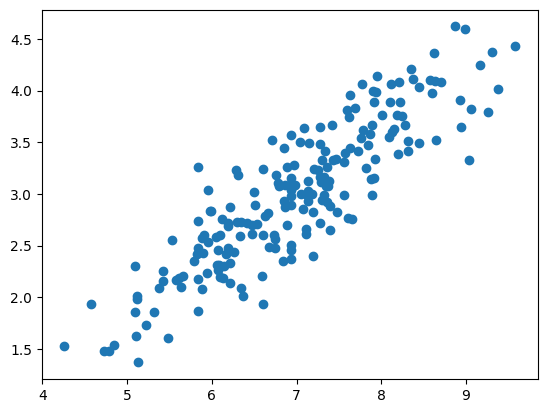

In [38]:
plt.scatter(df['cgpa'],df['package'])
plt.show()

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X = df.iloc[:,0:1]
y = df.iloc[:,1]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [42]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [43]:
lr.fit(X_train,y_train)

LinearRegression()

In [44]:
y_pred= lr.predict(X_test)

In [45]:
y_pred

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

In [46]:
y_test

,package
112,4.10
29,3.49
182,2.08
199,2.33
193,1.94
85,1.48
10,1.86
54,3.09
115,4.21
35,2.87


In [47]:
y_pred - y_test

,package
112,-0.208884
29,-0.396755
182,0.304646
199,0.244349
193,-0.286271
85,0.296478
10,0.212193
54,-0.158561
115,-0.447213
35,0.067018


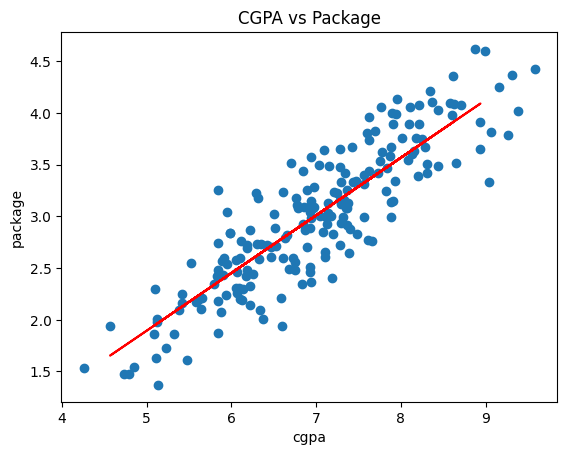

In [48]:
plt.scatter(df['cgpa'],df['package'])

plt.plot(X_test,y_pred,color='red')
plt.xlabel('cgpa')
plt.ylabel('package')
plt.title('CGPA vs Package')
plt.show()

In [49]:
m = lr.coef_
m

array([0.55795197])

In [50]:
b = lr.intercept_
b

np.float64(-0.8961119222429144)

In [51]:
m * 10 +b

array([4.68340781])

In [52]:
class MyLR:

  def __init__(self):
    self.m = None
    self.b = None

  def fit(self,X_train,y_train):
      num = 0
      den = 0
      for i in range(X_train.shape[0]):
        num = num + (X_train[i] - X_train.mean())*(y_train[i] - y_train.mean())
        den = den + (X_train[i] - X_train.mean())**2
      self.m = num/den
      self.b = y_train.mean() - (self.m * X_train.mean())
      print(self.m)
      print(self.b)

  def predict(self,X_test):
    return self.m * X_test + self.b

In [53]:
df = pd.read_csv('placement.csv')
X = df.iloc[:,0].values
y = df.iloc[:,1].values

In [54]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [55]:
lr = MyLR()

In [56]:
lr.fit(X_train,y_train)

0.5579519734250721
-0.8961119222429152


In [57]:
lr.predict(X_test[0])

np.float64(3.891116009744203)

In [58]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [59]:
y_pred = lr.predict(X_test)

In [60]:
y_test

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [61]:
print('MAE:',mean_absolute_error(y_test,y_pred))
print('MSE:',mean_squared_error(y_test,y_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred)))
print('R2 Score:',r2_score(y_test,y_pred))

MAE: 0.2884710931878174
MSE: 0.12129235313495523
RMSE: 0.3482705171773161
R2 Score: 0.7807301475103842


In [62]:
#Adjusted R2 score
r2 = r2_score(y_test,y_pred)
n = X_test.shape[0]
p = 1
adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)

In [63]:
adjusted_r2

0.7749598882343417

In [64]:
new_df = df.copy()

new_df['random_feature'] = np.random.random(200)
new_df = new_df[['cgpa','random_feature','package']]

In [65]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
from sklearn.model_selection import train_test_split
X = new_df.drop('package',axis=1)
y = new_df['package']

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [67]:
lr.fit(X_train,y_train)

LinearRegression()

In [68]:
y_pred = lr.predict(X_test)

In [69]:
print('R2 Score:',r2_score(y_test,y_pred))

R2 Score: 0.7811602107862524


In [70]:
#Adjusted R2 score
r2 = r2_score(y_test,y_pred)
n = X_test.shape[0]
p = 2
adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
adjusted_r2

0.7693310329909147

In [71]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [72]:
X,y = make_regression(n_samples = 100, n_features = 2, n_informative=2, n_targets=1, noise=50)

In [73]:
df = pd.DataFrame(X,columns=['x1','x2'])
df['y'] = y

In [74]:
df.head()

,x1,x2,y
0,0.483431,-0.700764,15.899578
1,-2.249893,-1.041567,-14.198915
2,-2.250252,0.930201,31.115482
3,0.179738,0.591119,-39.921769
4,-1.066660,-1.111231,-90.153288


In [75]:
df.shape

(100, 3)

In [76]:
fig = px.scatter_3d(df,x='x1',y='x2',z='y')
fig.show()

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

In [78]:
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [79]:
y_pred = lr.predict(X_test)

In [80]:
print('MSE:',mean_squared_error(y_test,y_pred))
print('R2 Score:',r2_score(y_test,y_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred)))
print('MAE', mean_absolute_error(y_test,y_pred))

MSE: 2320.551027995518
R2 Score: -0.5304491528024065
RMSE: 48.17209802360198
MAE 36.85304130102712


In [81]:
x = np.linspace(-5,5,10)
y = np.linspace(-5,5,10)

xGrid, yGrid = np.meshgrid(y,x)



final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T
z_final = lr.predict(final).reshape(10,10)
z = z_final

In [82]:
fig = px.scatter_3d(df,x='x1',y='x2',z='y')
fig.add_trace(go.Surface(x=x,y=y,z=z_final))
fig.show()

In [83]:
lr.coef_

array([ 5.62769084, 31.89796235])

In [84]:
lr.intercept_

np.float64(0.16624504390258732)

In [85]:
import numpy as np
from sklearn.datasets import load_diabetes
X,y = load_diabetes(return_X_y=True)

In [86]:
X

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]])

In [87]:
X.shape, y.shape

((442, 10), (442,))

In [88]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
print(X_train.shape)
print(X_test.shape)

(353, 10)
(89, 10)


In [89]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [90]:
y_pred = reg.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.4399338661568968

In [91]:
reg.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [92]:
reg.intercept_

np.float64(151.88331005254167)

Code from scratch

In [115]:
class MeraLR:

  def __init__(self):
    self.coef_ = None
    self.intercept_ = None

  def fit(self,X_train,y_train):
    X_train = np.insert(X_train,0,1,axis=1)

    betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
    self.intercept_ = betas[0]
    self.coef_ = betas[1:]

  def predict(self,test):
    y_pred = np.dot(X_test,self.coef_) + self.intercept_
    return y_pred

In [116]:
lr = MeraLR()

In [117]:
lr.fit(X_train,y_train)


In [118]:
y_pred = lr.predict(X_test)

In [119]:
r2_score(y_test,y_pred)

0.43993386615689634

In [120]:
lr.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [121]:
lr.intercept_

np.float64(151.88331005254165)

Linear Regression Assumptions

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [123]:
df = pd.read_csv('data.csv')

In [124]:
X = df.iloc[:,0:3].values
y = df.iloc[:,-1].values
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [125]:

# Residual
y_pred = model.predict(X_test)
residual = y_test - y_pred

In [126]:
y_pred, residual

(array([ -34.76883341,  190.67135514,   14.04224122,  -16.3715581 ,
         118.17558768, -107.77390191,  -40.20553863,   93.06420644,
          -7.3512859 ,   28.47554765,   15.26138536, -107.45700707,
          64.50359715,  143.2359111 ,  -20.97314353,  137.79488969,
         -50.72450467,  168.27219255,   60.80874417,  179.43251544,
          32.66581961,   21.10166299,   69.55019994,  -13.04136716,
          -1.88792469, -106.29378502,  179.16218587, -120.92336473,
         -31.51039885,  134.36018807,  107.13086641,  -10.52841354,
           6.92995851,   53.08006944,   27.61938445,  -47.06498585,
          13.63636605,  102.93836476,  -50.85751435,   80.16839852,
         171.72181145,  -21.9406968 , -124.23145342,  -64.56750574,
        -106.29193084,  -99.41609941,  -51.73488661,  108.17430767,
        -156.29911188,  160.99011399,  -58.12394403,  -58.3330757 ,
          25.06769006,   24.78558548,   86.34740515,   14.38094821,
         -16.70618586,   54.61570835,  -40.02749

1. Linear Relationship

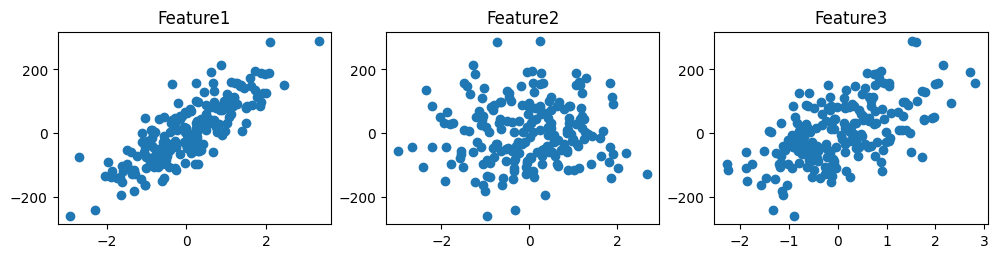

In [127]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title("Feature1")
ax2.scatter(df['feature2'], df['target'])
ax2.set_title("Feature2")
ax3.scatter(df['feature3'], df['target'])
ax3.set_title("Feature3")

plt.show()

2. Multicollinearity

In [129]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))


In [130]:
pd.DataFrame({'vif': vif}, index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.010326,1.009871,1.01395


<Axes: >

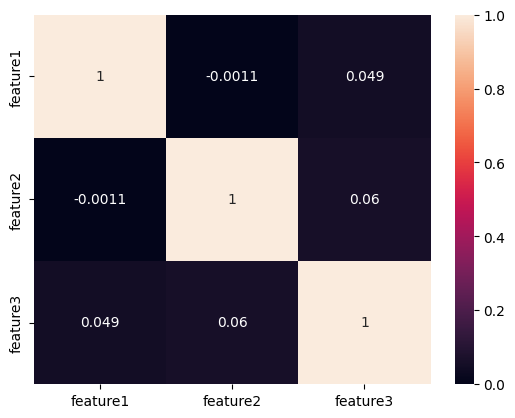

In [131]:
# Another Technique
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)

3. Normality of Residual

<Axes: ylabel='Density'>

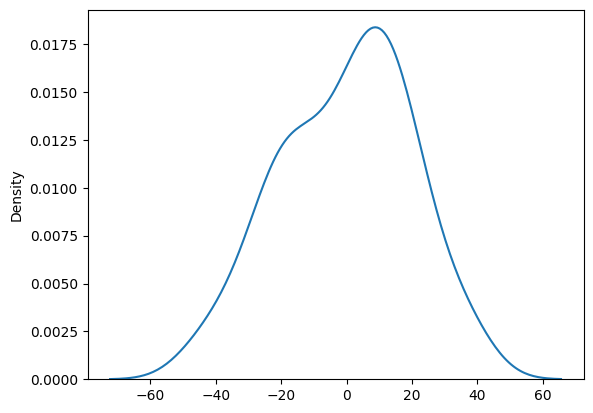

In [132]:
sns.kdeplot(residual)

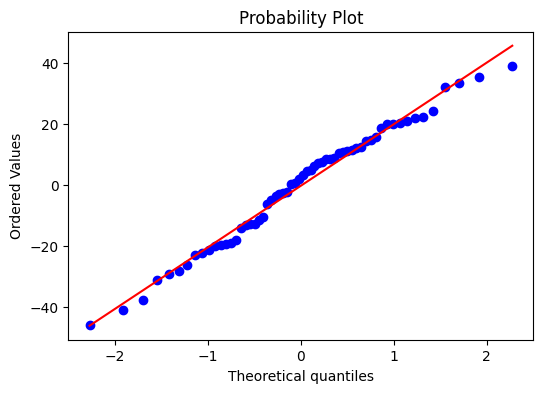

In [134]:
import scipy as sp

fig,ax =plt.subplots(figsize = (6,4))
sp.stats.probplot(residual, fit = True, plot=ax)
plt.show()

4. Homoscedasticity

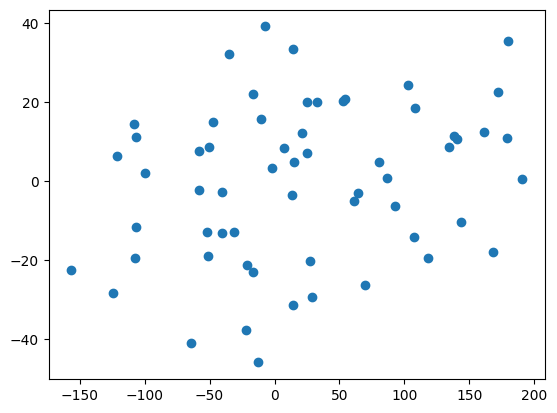

In [135]:
plt.scatter(x= y_pred, y = residual)

5. No autocorrelation of Residuals

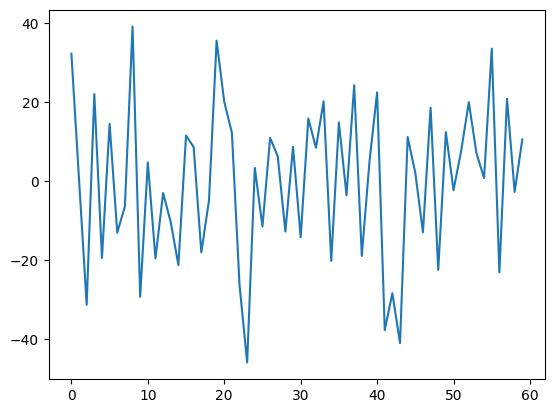

In [136]:
plt.plot(residual)